<a href="https://colab.research.google.com/github/AryanSaxena1808/AryanSaxena1808.github.io/blob/main/TechnicalTask_Aryan_Saxena.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv('/content/python_test_dataset_flights_6months.csv')

In [ ]:
df.head()

,buyer_id,supplier_id,to_airport,from_airport,journey_type,pax,costprice,markup,selling_price,booking_date,payment_method,refund_status,refund_amount,channel_of_booking,booking_status,travel_date,cashback,coupon_redeem,Coupon USed?
0,492,3,CCU,ATL,round trip,4,422.296189,92.138566,537.469396,2024-03-01,PayPal,Yes,369.648995,Web,confirmed,04-03-2024,5.374694,0.000000,No
1,299,3,HYD,HYD,round trip,2,692.981884,375.363227,1162.185918,2024-03-01,Credit Card,Yes,799.302917,Web,confirmed,14-05-2023,11.621859,0.000000,No
2,64,4,BLR,SEA,one way,3,797.788149,404.749466,1303.724982,2024-03-01,Bank Transfer,Yes,896.647571,Web,confirmed,26-09-2023,0.000000,0.000000,No
3,345,6,DEL,DEN,one way,2,286.472882,92.202248,363.308088,2024-03-01,Credit Card,Yes,249.868124,Android,confirmed,17-10-2024,0.000000,9.220225,Yes
4,31,6,DEL,BOM,one way,4,840.560581,173.595343,1057.554760,2024-03-01,Debit Card,Yes,727.341978,Web,confirmed,11-09-2023,0.000000,0.000000,No


In [ ]:
df.shape

(32240, 19)

# **Observation 1**

In [ ]:
df.groupby('payment_method').size()

,0
payment_method,
Bank Transfer,8026
Credit Card,8098
Debit Card,8003
PayPal,8113


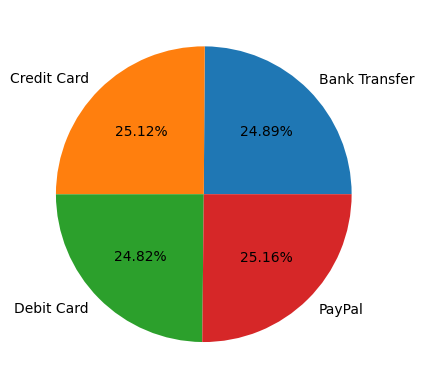

In [ ]:
pay = ['Bank Transfer','Credit Card', 'Debit Card','PayPal']
pay_count = [8026,8098,8003,8113]
plt.pie(pay_count, labels=pay, autopct='%.2f%%')
plt.show()

# **Observation 2 **

In [ ]:
df.groupby('channel_of_booking').size()

,0
channel_of_booking,
Android,9672
Web,16120
iOS,6448


<BarContainer object of 3 artists>

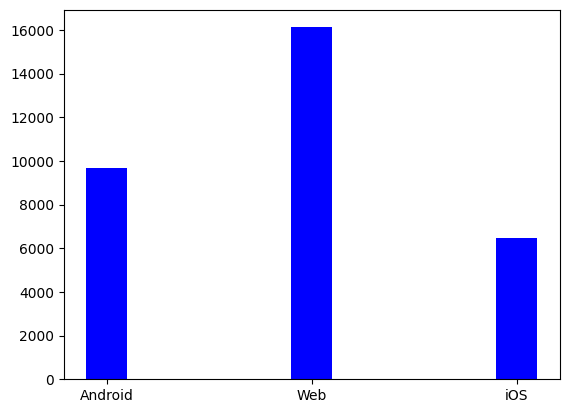

In [ ]:
book_data = {'Android': 9672, 'Web': 16120, 'iOS': 6448}
channel = list(book_data.keys())
count = list(book_data.values())
plt.bar(channel,count, color = 'blue', width = 0.2)

# **Observation 3**

In [ ]:
df.groupby('Coupon USed?').size()

,0
Coupon USed?,
No,20871
Yes,11369


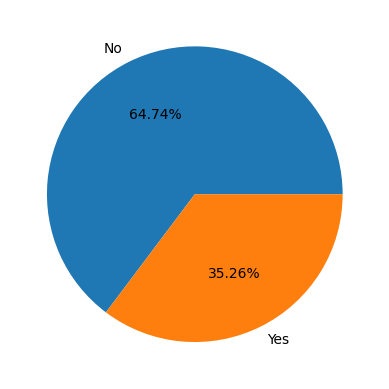

In [ ]:
used = ['No','Yes']
coupon_count = [20871,11369]
plt.pie(coupon_count, labels=used, autopct='%.2f%%')
plt.show()

# **Strategy 1**

In [ ]:
df.groupby('travel_date').size()

,0
travel_date,
01-01-2023,57
01-01-2024,54
01-02-2023,53
01-02-2024,52
01-03-2023,43
...,...
31-08-2024,36
31-10-2023,41
31-10-2024,36


In [ ]:
df['travel_date'] = pd.to_datetime(df['travel_date'], format="%d-%m-%Y")
grouped_data = df.groupby(pd.Grouper(key='travel_date', freq='M')).size()
sorted_data = grouped_data.sort_values(ascending=False)
top_10_data = sorted_data.head(10)
result_df = pd.DataFrame({'Month': top_10_data.index.get_level_values(0).strftime('%Y-%m'), 'Count': top_10_data.values})
print(result_df)

     Month  Count
0  2023-01   1642
1  2024-12   1570
2  2024-10   1555
3  2024-03   1549
4  2023-08   1511
5  2024-01   1487
6  2024-08   1481
7  2023-07   1473
8  2023-11   1467
9  2023-10   1451


# **Strategy 2**

In [ ]:
grouped_data=df.groupby('to_airport').size()
sorted_data = grouped_data.sort_values(ascending=False)
top_10_data = sorted_data.head(10)
print(top_10_data)

to_airport
PNQ    1991
JAI    1981
DEL    1973
AMD    1924
HYD    1919
MAA    1919
BLR    1873
BOM    1872
CCU    1862
GOI    1859
dtype: int64


<BarContainer object of 10 artists>

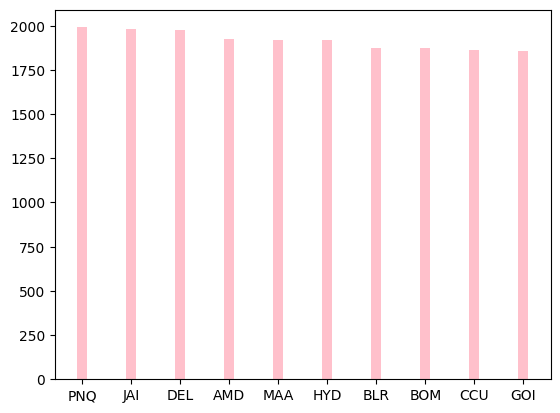

In [ ]:
air_data = {'PNQ': 1991, 'JAI': 1981, 'DEL': 1973, 'AMD': 1924, 'MAA': 1919, 'HYD': 1919, 'BLR': 1873, 'BOM': 1872, 'CCU': 1862, 'GOI': 1859}
air = list(air_data.keys())
count = list(air_data.values())
plt.bar(air,count, color = 'pink', width = 0.2)

# **Strategy 3**

In [ ]:
df.groupby('supplier_id').size()

,0
supplier_id,
1,3944
2,4838
3,3853
4,4799
5,4955
6,4880
7,4971


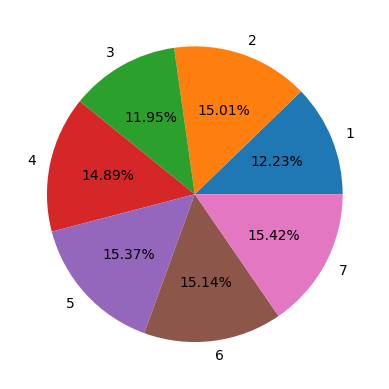

In [ ]:
id_data = [1,2,3,4,5,6,7]
id_count = [3944,4838,3853,4799,4955,4880,4971]
plt.pie(id_count, labels=id_data, autopct='%.2f%%')
plt.show()